In [1]:
import sys
sys.path.append("../src/")
%load_ext autoreload
%autoreload 2

In [2]:
from generators.toy_problem_to_json import toy_problem_to_json # type: ignore[reportMissingImports]
from relaxers.quadratic_model_lin_approx import quadratic_model_lin_approx # type: ignore[reportMissingImports]
from relaxers.quadratic_lin_approx_no_surrogate import quadratic_lin_approx_no_surrogate # type: ignore[reportMissingImports]
from testers.classical_solve_lin_program import solve_lp # type: ignore[reportMissingImports]
from testers.classical_solve_quad_program import solve_qcp # type: ignore[reportMissingImports]
import matplotlib.pyplot as plt
import numpy as np

true_false = (True, False)

This notebook is for experimenting on with linear approximations to the toy problem or the GasNet-11 problem.

You can download the relevant GasNet-11 files from Sergey's emails.

Some conclusions:
- The condition number is stable with the bound constraints for the toy problem but goes to infinity without them (is there an eigenvalue of 0?)
- The condition number is a bit higher in general for the real problem but still manageable without the bound constraints.
- Most bound constraint parameters to the linear approximation don't affect the condition number. Some (N, lambda) are hard to check because the toy problem seems to have odd properties compared to the real problem. The condition number is linearly proportional to the number of linear constraints. The effect of if the coefficient is included in the surrogate is large and very different depending on toy vs. real.

In [3]:
# Number of copies of the network in the toy system
N=20

# Whether the production and flow variables have upper bounds
F_UPPER_BOUNDS=True

# Whether the demand constraint is an equality or inequality
DEMAND_INEQUALITY=True

# Capacity / demand parameters
# GAMMA=1.0
GAMMA=1.0
LAMBD=1.0
EPS=0.1
DELTA=0.1

# Lower bounds and upper bound on pressure
LX=LP=LF=0.0
UP=5.0

# The number of linear constraints to use per quadratic constraint
LIN_CONSTRAINTS = 20

# Whether to do an inner or outer approximation
OUTER_APPROXIMATION = True

# Whether the coefficient is part of the surrogate
COEFFICIENT_SURROGATE = True

# Whether to bound the surrogates with bound constraints.
SURROGATE_BOUND_BELOW = True
SURROGATE_BOUND_ABOVE = True

# Whether to divide by lambda in an inner approximation
REMOVE_DIVISION = False

In [ ]:
# Put the original QCP into gurobi
qcp_value, qcp_time = solve_qcp(f_name="model11_quad_reform_nofix.json")
print(qcp_value, qcp_time)

Set parameter Username
Set parameter LicenseID to value 2823041
Academic license - for non-commercial use only - expires 2027-05-16
2914.0372553299326 0.0019998550415039062


In [7]:
print(solve_lp(f_name="Model11_lp_nofix.json"))
print(solve_qcp(f_name="Model11_lp_nofix.json"))

(2730.754328545064, 0.0)
(2730.754328544699, 0.0010001659393310547)


-0.019978393256678828
-1.4336252510511258


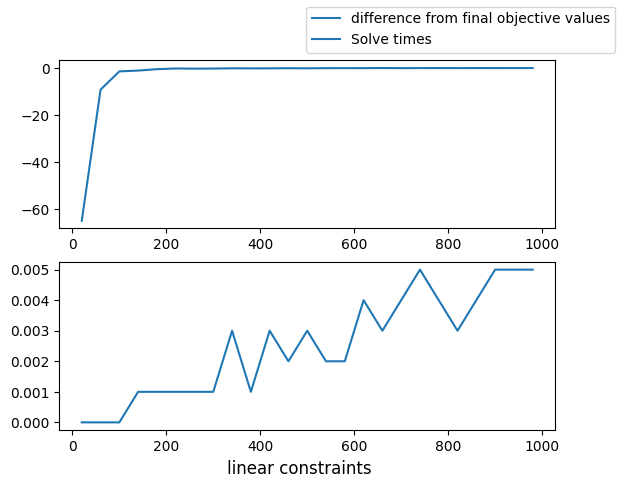

In [8]:
errors = []
times = []

# Model may be infeasible if this is not big enough
# lin_cons_range = range(2, 101, 4)
lin_cons_range = range(20, 1001, 40)

for lin_cons in lin_cons_range:
    # quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
    #                             SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, endpoints=False,
    #                             f_name="model11_quad_reform_2.json", remove_division=REMOVE_DIVISION)
    quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION, endpoints=True,
                                        f_name="model11_quad_reform_nofix.json", remove_division=REMOVE_DIVISION)
    val, time = solve_lp()
    if qcp_value is not None and val is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("linear constraints")
ax1.plot(lin_cons_range, errors, label="difference from final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

-0.13134987748026106
-10.652577046242186


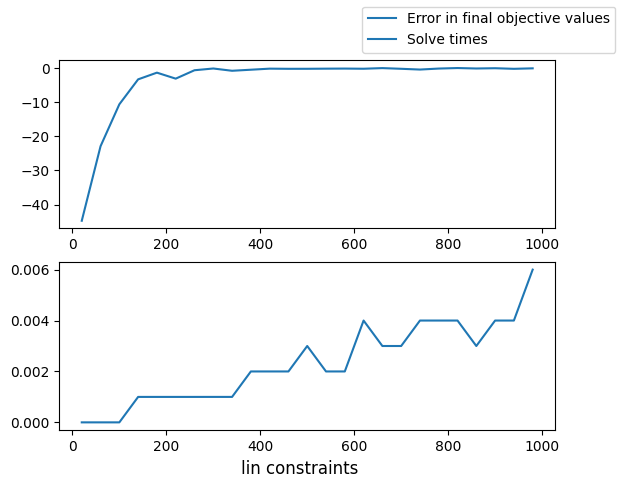

In [10]:
# Tends to be infeasible for inner approximation
if OUTER_APPROXIMATION:
    rng = np.random.default_rng()

    errors = []
    times = []
    # lin_cons_range = range(2, 101, 4)
    lin_cons_range = range(20, 1001, 40)
    for lin_cons in lin_cons_range:
        quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                    SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                    points_function=rng.uniform, remove_division=REMOVE_DIVISION,
                                    f_name="model11_quad_reform_nofix.json")
        # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
        #                                     points_function=rng.uniform, remove_division=REMOVE_DIVISION,
        #                                     f_name="model11_quad_reform_2.json")
        val, time = solve_lp()
        if val is not None and qcp_value is not None:
            errors.append(val - qcp_value)
            times.append(time)

    fig, (ax1, ax2) = plt.subplots(2, 1)
    fig.supxlabel("lin constraints")
    ax1.plot(lin_cons_range, errors, label="Error in final objective values")
    ax2.plot(lin_cons_range, times, label="Solve times")
    fig.legend()

    print(errors[-1])
    print(errors[2])

In [ ]:
concat = 1.67

def np_uniform_bunch_low(lower: float, upper: float, num: int):
    return np.linspace(lower, lower + ((upper - lower)/concat), num)

def np_uniform_bunch_high(lower: float, upper: float, num: int):
    return np.linspace(upper - ((upper - lower) / concat), upper, num)

def np_uniform_bunch_middle(lower: float, upper: float, num: int):
    midpoint = (lower + upper) / 2
    return np.linspace(midpoint - ((upper - lower) / (2*concat)), midpoint + ((upper - lower)/(2*concat)), num)

-0.02202010003338728
-1.1682725322270926


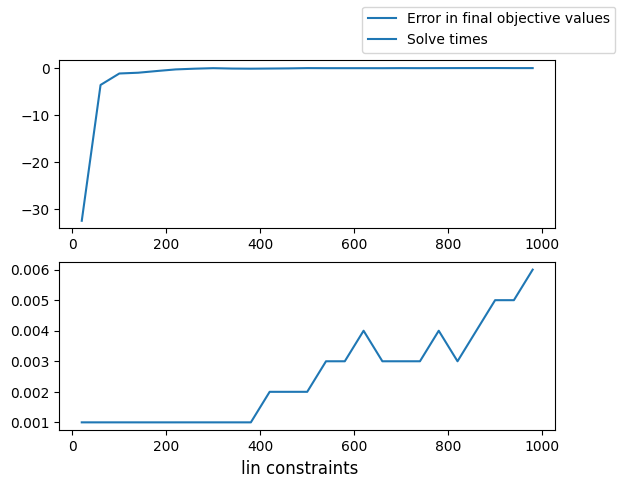

In [30]:
errors = []
times = []
# lin_cons_range = range(2, 101, 4)
lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
                                f_name="model11_quad_reform_nofix.json")
    # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
    #                                     points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
    #                                     f_name="model11_quad_reform_2.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("lin constraints")
ax1.plot(lin_cons_range, errors, label="Error in final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

-61.03368730431748
-61.0524948252405


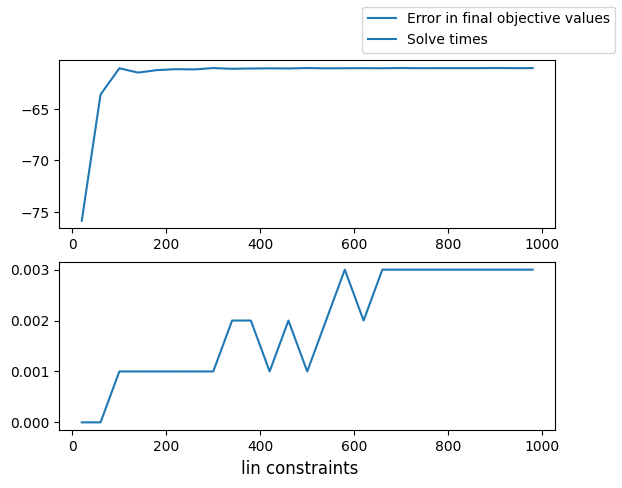

In [31]:
errors = []
times = []
# lin_cons_range = range(2, 101, 4)
lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                points_function=np_uniform_bunch_high, remove_division=REMOVE_DIVISION,
                                f_name="model11_quad_reform_nofix.json")
    # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
    #                                     points_function=np_uniform_bunch_high, remove_division=REMOVE_DIVISION,
    #                                     f_name="model11_quad_reform_2.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("lin constraints")
ax1.plot(lin_cons_range, errors, label="Error in final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

-0.2869966916800877
-0.939619099716765


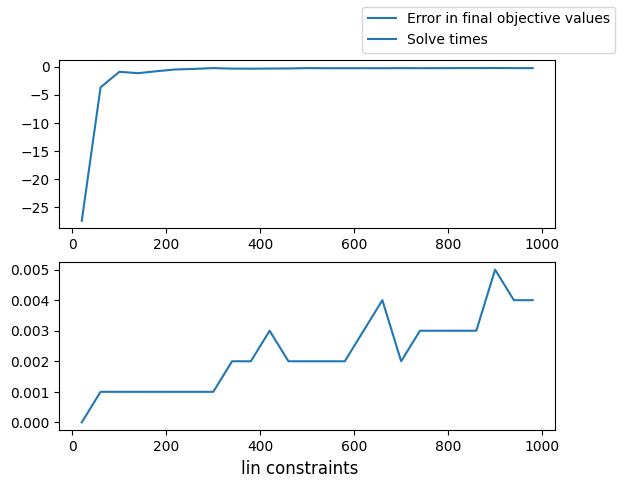

In [32]:
errors = []
times = []
# lin_cons_range = range(2, 101, 4)
lin_cons_range = range(20, 1001, 40)
for lin_cons in lin_cons_range:
    quadratic_model_lin_approx(lin_cons, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE,
                                points_function=np_uniform_bunch_middle, remove_division=REMOVE_DIVISION,
                                f_name="model11_quad_reform_nofix.json")
    # quadratic_lin_approx_no_surrogate(lin_cons, OUTER_APPROXIMATION,
    #                                     points_function=np_uniform_bunch_middle, remove_division=REMOVE_DIVISION,
    #                                     f_name="model11_quad_reform_2.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("lin constraints")
ax1.plot(lin_cons_range, errors, label="Error in final objective values")
ax2.plot(lin_cons_range, times, label="Solve times")
fig.legend()

print(errors[-1])
print(errors[2])

1.6326530612244898


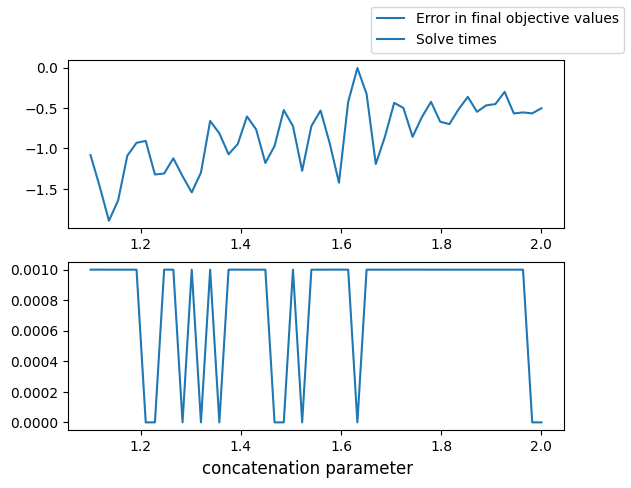

In [ ]:
points = np.linspace(1.1, 2, 50, endpoint=True)
LIN_CONSTRAINTS = 100

errors = []
times = []
for concat in points:
    
    def np_uniform_bunch_low(lower: float, upper: float, num: int):
        return np.linspace(lower, lower + ((upper - lower)/concat), num)

    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, endpoints=False,
                                points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
                                f_name="model11_quad_reform_nofix.json")
    # quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION,
    #                                     points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
    #                                     f_name="model11_quad_reform_nofix.json")
    val, time = solve_lp()
    if val is not None and qcp_value is not None:
        errors.append(val - qcp_value)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("concatenation parameter")
ax1.plot(points, errors, label="Error in final objective values")
ax2.plot(points, times, label="Solve times")
fig.legend()

print(points[np.argmin(np.abs(errors))])

quad: 102.74260073589001
102.39399130810415
102.34617069361937
102.29413803867214
102.23809427098746
102.17822773846842
102.11471517852974
102.0477225991652
101.97740608098054
101.9039125083424
101.82738023684838
101.74793970349185
101.66571398518529
101.58081931066799
101.49336553027092
101.40345654754142
101.31119071628142
101.2166612061993
101.11995634002393
101.02115990465049
100.92932796413949
100.83816254946846
100.74534262973073
100.65092881773084
100.55497880125907
100.45754751742824
100.35868731469274
100.25844810354437
100.15687749680563
100.05402094034365
100.00000000000001
100.00000000000001
100.00000000000001
100.00000000000001
100.00000000000001
100.00000000000001
100.00000000000001
100.00000000000001
100.00000000000001
100.00000000000001
100.00000000000018
100.0000000000001
100.00000000000018
100.00000000000017
100.0
100.00000000000017
100.0
100.0
100.00000000000016
100.00000000000014
100.00000000000011
1.1


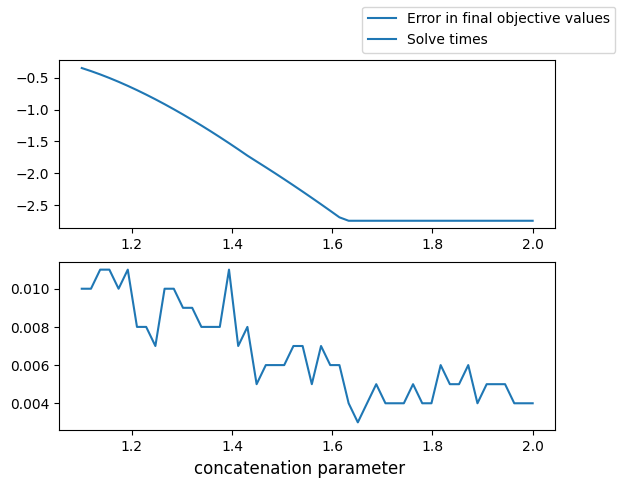

In [17]:
points = np.linspace(1.1, 2, 50, endpoint=True)
N = 100
GAMMA = 3.0
LAMBD = 1.0
LIN_CONSTRAINTS = 3

errors = []
times = []
toy_problem_to_json(N, F_UPPER_BOUNDS, DEMAND_INEQUALITY, GAMMA, LAMBD,
                    EPS, DELTA, LP, LF, UP)
quad, q_time = solve_qcp(f_name="toy.json")
print(f"quad: {quad}")

for concat in points:
    
    def np_uniform_bunch_low(lower: float, upper: float, num: int):
        return np.linspace(lower, lower + ((upper - lower)/concat), num)

    quadratic_model_lin_approx(LIN_CONSTRAINTS, OUTER_APPROXIMATION, COEFFICIENT_SURROGATE,
                                SURROGATE_BOUND_BELOW, SURROGATE_BOUND_ABOVE, endpoints=False,
                                points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
                                f_name="toy.json")
    # quadratic_lin_approx_no_surrogate(LIN_CONSTRAINTS, OUTER_APPROXIMATION,
    #                                     points_function=np_uniform_bunch_low, remove_division=REMOVE_DIVISION,
    #                                     f_name="toy.json")
    val, time = solve_lp()
    print(val)
    if val is not None and quad is not None:
        errors.append(val - quad)
        times.append(time)

fig, (ax1, ax2) = plt.subplots(2, 1)
fig.supxlabel("concatenation parameter")
ax1.plot(points, errors, label="Error in final objective values")
ax2.plot(points, times, label="Solve times")
fig.legend()

print(points[np.argmin(np.abs(errors))])